In [21]:
# Combine Time-Dependence and SimpleDiff

import numpy as np
import pandas as pd
from scipy.optimize import minimize
from sympy import *
import matplotlib.pyplot as plt
init_printing(use_latex=true)
filename = "TestDataLots.xlsx"

In [22]:
# Establish symbols
n, T, k, i, t, lda, eps = symbols('n T k i t \lambda \epsilon')       
# n wells & T timepoints
# k = highest degree of w polynomial

In [23]:
# Choose highest degree of polynomial
k = 3

In [24]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

5

In [25]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

41

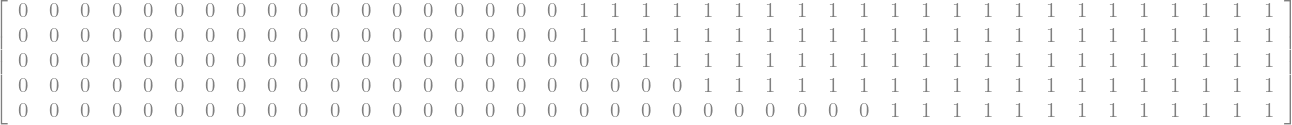

In [26]:
# Establish binary matrix for wells being on or off
z = MatrixSymbol('z', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(z.as_explicit())
zReal = Matrix(pd.read_excel(filename, sheet_name="OnOff").to_numpy().T)
zReal

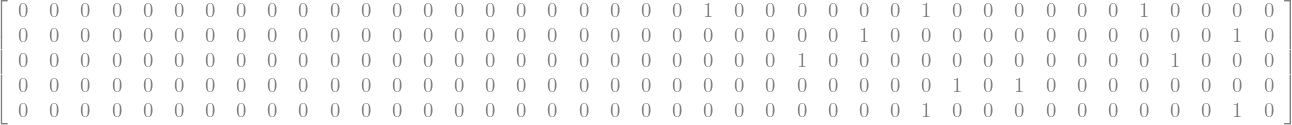

In [27]:
# Establish binary matrix for wells being measured or not
d = MatrixSymbol('d', n, T)      # Row 0 = well 0   , Column 3 = Timepoint 3
#pprint(d.as_explicit())
dReal = Matrix(pd.read_excel(filename, sheet_name="Measured").to_numpy().T)
dTotal = sum(dReal)
dReal

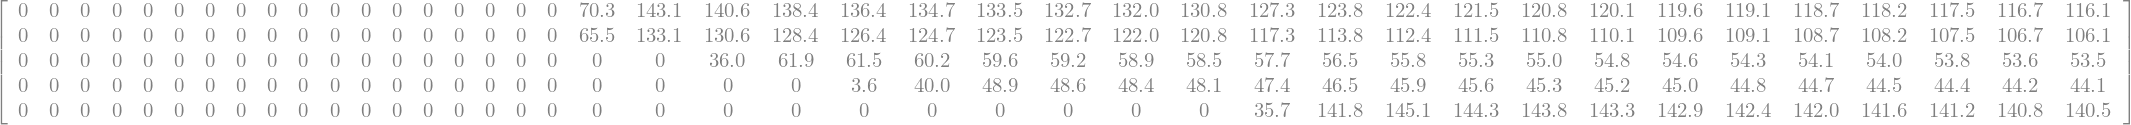

In [28]:
# Establish matrix of actual mass flows
m = MatrixSymbol('m', n, T)  
#pprint(m.as_explicit())
mReal = Matrix(pd.read_excel(filename, sheet_name="MassFlows").to_numpy().T)
mReal

In [29]:
# Establish matrix / vector of total mass flow
M = MatrixSymbol('M', 1, T)
#pprint(M.as_explicit())
MReal = Matrix(pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T)
MReal

In [30]:
# Set w as an expression based on t
wMat = MatrixSymbol('w', n, k+1)
pprint(wMat.as_explicit())

⎡w₀₀  w₀₁  w₀₂  w₀₃⎤
⎢                  ⎥
⎢w₁₀  w₁₁  w₁₂  w₁₃⎥
⎢                  ⎥
⎢w₂₀  w₂₁  w₂₂  w₂₃⎥
⎢                  ⎥
⎢w₃₀  w₃₁  w₃₂  w₃₃⎥
⎢                  ⎥
⎣w₄₀  w₄₁  w₄₂  w₄₃⎦


In [31]:
# Instantaneous value of wi is wMati * [1, t, t^2, t^3 etc]
tList = []
for power in range(k+1):
    tList.append(t**power)
ts = Matrix(tList)
wInstant = Matrix([wMat[i,:].as_explicit().dot(ts) for i in range(n)])
wInstant[0,0]

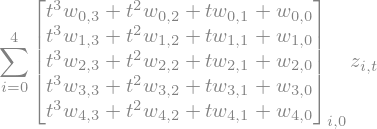

In [32]:
Sum(z[i, t]*wInstant[i, 0], (i, 0, n-1))

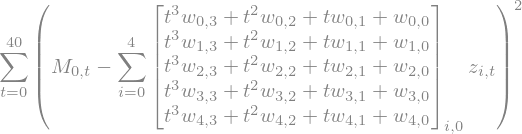

In [33]:
S1 = Sum((M[0,t] - Sum(z[i, t]*wInstant[i,0], (i, 0, n-1)))**2 , (t, 0, T-1))
S1

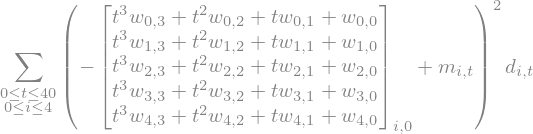

In [34]:
S2 = Sum(Sum(d[i,t]*((m[i,t]-wInstant[i,0]))**2 , (t, 0, T-1)), (i, 0, n-1))
S2

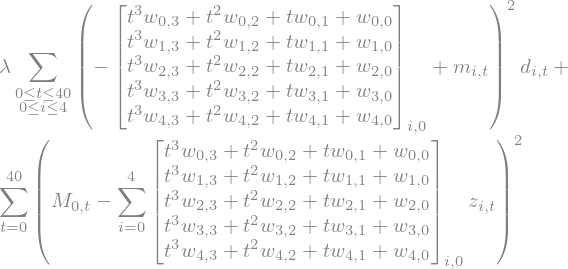

In [35]:
I = S1 + lda*S2
I

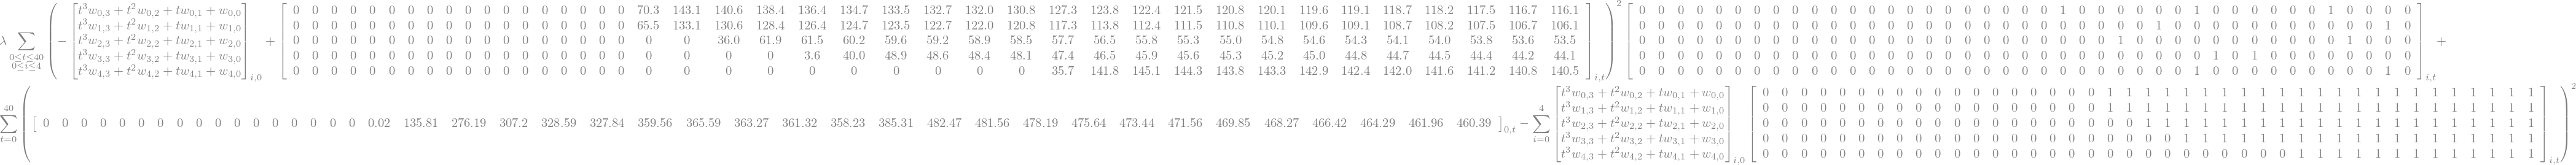

In [36]:
Inac = I.subs({M: MReal, z: zReal, d: dReal, m: mReal})
Inac

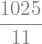

In [37]:
optLda = T*n**2/dTotal
Inaccuracy = Inac.subs(lda, optLda)
optLda

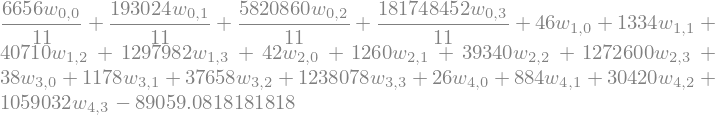

In [40]:
Inaccuracy.diff(wMat[0,0]).doit()

In [ ]:
DiffA = np.zeros([(k+1)*n,(k+1)*n])
Diffb = np.zeros((k+1)*n)
# Fill in matrix with values for Aw=b  
for i in range(n):
    for j in range(k+1):
        # v = vertical index
        v = i*(k+1)+j
        dwij = Poly(Inaccuracy.diff(wMat[i,j]).doit())
        Diffb[v] = -1*dwij.coeffs()[-1]
        for i2 in range(n):
            for j2 in range(k+1):
                # h = horizontal index
                h = i2*(k+1)+j2
                #print(v, h)
                DiffA[v,h] = dwij.coeff_monomial(wMat[i2, j2])
                
    
# Then solve for w
DiffMatrixA = Matrix(DiffA)
DiffMatrixb = Matrix(Diffb)
DiffMatrixA

In [ ]:
DiffMatrixb

In [ ]:
results = DiffMatrixA.inv()*DiffMatrixb
results

In [ ]:
wExpr = results.reshape(n, k+1)*ts
wExpr

In [ ]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k']
for i in range(n):
    plt.plot(range(T),mReal[i,:][:], colours[i]+'-', lw=2, label="Real flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for t in range(T):
        resplot = wExpr[i].subs(t, t)
        toplot.append(resplot*zReal[i,t])
    plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(dReal[i,:]):
        if element==1:
            monthplot.append(month)
            tftplot.append(mReal[i,month])
    plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
            
plt.title("Estimated and real mass flows over time by well")
plt.xlabel("Time (month)")
plt.ylabel("Mass Flow (kg/s)")
plt.legend()


In [ ]:
# Plot total flow vs found total flow
totalFlowFound = np.zeros((T,1))
times = range(T)
for t in range(T):
    tff = [wExpr[i].subs(time, t)*zReal[i,t] for i in range(n)]
    #print(t, tff)
    totalFlowFound[t] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal), 'g-', lw=2, label="Real Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Estimated Total Mass Flow")

plt.title("Estimated and real total mass flows over time")
plt.xlabel("Time (month)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()

In [ ]:
Bayesian model based on normal distribution of provided data. Bishop book